In [1]:
from env import (
    MultiLeafThreadEnv,
    ThreadingConfig,
)
import torch
import random
from viz import draw_local_tree_sequence, draw_tree_edge_index
from utils import _timed_tree_to_graph_full
import matplotlib.pyplot as plt


In [2]:
REFERENCE_FULL_TREES = [
    {
        "sites": (0, 4),
        "tree": ("n", 2.0, ("n", 0.5, 0, 1), ("n", 1.0, 2, 3)),
    },
    {
        "sites": (4, 8),
        "tree": ("n", 2.0, ("n", 0.5, 0, 2), ("n", 1.0, 1, 3)),
    },
]

GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)


In [3]:
multi_env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
multi_env = MultiLeafThreadEnv(multi_env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)


In [4]:
st, reward, actions = multi_env.generate_random_trajectory()

{'edge_index': tensor([[3, 3, 4, 4, 6, 6],
        [1, 2, 0, 3, 4, 5]]), 'num_nodes': 7, 'root': 6, 'node_times': tensor([0.0000, 0.0000, 0.0000, 0.2500, 0.2500, 0.0000, 1.0000]), 'node_sample_ids': (2, 0, 3, -1, -1, 1, -1), 'start': 0, 'end': 1}
{'edge_index': tensor([[4, 4, 5, 5, 6, 6],
        [2, 3, 1, 4, 0, 5]]), 'num_nodes': 7, 'root': 6, 'node_times': tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.5000, 1.0000]), 'node_sample_ids': (0, 1, 2, 3, -1, -1, -1), 'start': 1, 'end': 2}
{'edge_index': tensor([[3, 3, 5, 5, 6, 6],
        [1, 2, 3, 4, 0, 5]]), 'num_nodes': 7, 'root': 6, 'node_times': tensor([0.0000, 0.0000, 0.0000, 0.2500, 0.0000, 0.5000, 0.5000]), 'node_sample_ids': (0, 1, 2, -1, 3, -1, -1), 'start': 2, 'end': 3}
{'edge_index': tensor([[4, 4, 5, 5, 6, 6],
        [2, 3, 1, 4, 0, 5]]), 'num_nodes': 7, 'root': 6, 'node_times': tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.2500, 0.2500, 0.2500]), 'node_sample_ids': (1, 0, 2, 3, -1, -1, -1), 'start': 3, 'end': 4}
{'edge_index

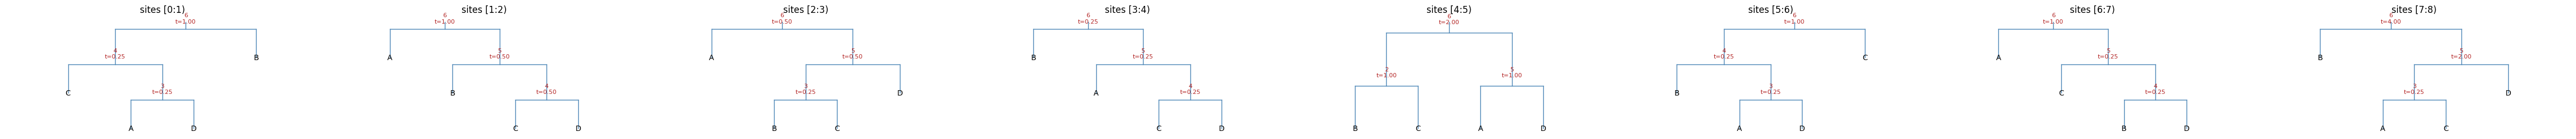

In [5]:

# Convert the timed tree tuple format into graphs expected by the visualizer
rendered_trees = []
for item in st.current_full_trees:
    start, end = item["sites"]
    edge_index, num_nodes, root, node_times, node_sample_ids = _timed_tree_to_graph_full(item["tree"])
    
    rendered_trees.append({
        "edge_index": edge_index,
        "num_nodes": num_nodes,
        "root": root,
        "node_times": node_times,
        "node_sample_ids": node_sample_ids,
        "start": start,
        "end": end,
    })

# Draw the sequence, passing your leaf names if you have them defined!
draw_local_tree_sequence(rendered_trees, leaf_names=["A", "B", "C", "D"])
